#  Data Sources
This project exclusively fetches air quality data from the following two primary sources:

1. **OpenAQ API** (`api.openaq.org`): Provides real-time and historical measurements of PM2.5, PM10, NO2, SO2, CO, and O3.
2. **CPCB / data.gov.in**: Central Pollution Control Board (India) datasets, serving comprehensive historical city-day air quality metrics.

#  Data Sources
This project exclusively fetches air quality data from the following two primary sources:

1. **OpenAQ API** (): Provides real-time and historical measurements of PM2.5, PM10, NO2, SO2, CO, and O3.
2. **CPCB / data.gov.in**: Central Pollution Control Board (India) datasets, serving comprehensive historical city-day air quality metrics.

##  Module 1: Python Programming & Data Collection


In [108]:
# Install missing libs if needed 
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-q", "-m", "pip", "install", pkg])

for pkg in ["requests", "seaborn", "scikit-learn", "scipy"]:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        install(pkg)

# Core imports 
import warnings, os, io, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, pearsonr, spearmanr

# Plot style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 5)})

print(" All libraries loaded successfully!")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")


 All libraries loaded successfully!
NumPy 2.2.6 | Pandas 2.3.1


In [110]:
# fetching from OpenAQ API (Delhi measurements)
print(" Fetching from OpenAQ API ")
openaq_frames = []
try:
    url = "https://api.openaq.org/v2/measurements"
    params = {
        "city": "Delhi",
        "limit": 500,
        "page": 1,
        "order_by": "datetime",
        "sort": "desc",
        "parameter": ["pm25", "pm10", "no2", "so2", "co", "o3"],
    }
    r = requests.get(url, params=params, timeout=20)
    if r.status_code == 200:
        data = r.json().get("results", [])
        if data:
            rows = []
            for d in data:
                rows.append({
                    "datetime": d["date"]["utc"],
                    "city":     d.get("city", "Delhi"),
                    "parameter": d["parameter"],
                    "value":    d["value"],
                    "unit":     d["unit"],
                })
            openaq_df = pd.DataFrame(rows)
            openaq_df["datetime"] = pd.to_datetime(openaq_df["datetime"])
            openaq_pivot = openaq_df.pivot_table(
                index=["datetime","city"], columns="parameter",
                values="value", aggfunc="mean"
            ).reset_index()
            openaq_pivot.columns.name = None
            openaq_frames.append(openaq_pivot)
      print(f"  OpenAQ: {len(openaq_pivot)} rows fetched")
        else:
      print("  OpenAQ returned empty results (rate-limited). Skipping.")
    else:
    print(f"  OpenAQ status {r.status_code} — skipping")
except Exception as e:
  print(f"  OpenAQ error: {e}")


IndentationError: unindent does not match any outer indentation level (<string>, line 35)

In [ ]:
# fetching from data.gov.in / CPCB CSV
# Publicly available mirror on GitHub
print(" Fetching CPCB/data.gov.in dataset ")
CPCB_URL = (
    "https://raw.githubusercontent.com/sreejith-nair511/"
    "Air-pollution-forecasting-Indian-cities/main/"
    "Data/city_day.csv"
)
try:
    r = requests.get(CPCB_URL, timeout=30)
    if r.status_code == 200:
        cpcb_df = pd.read_csv(io.StringIO(r.text))
        cpcb_df.columns = [c.strip().lower().replace(" ","_") for c in cpcb_df.columns]
        if "date" in cpcb_df.columns:
            cpcb_df["datetime"] = pd.to_datetime(cpcb_df["date"], errors="coerce")
    print(f"  CPCB (data.gov.in mirror): {cpcb_df.shape[0]} rows × {cpcb_df.shape[1]} cols")
    print(f"   Columns: {list(cpcb_df.columns[:10])} ")
    else:
        raise ValueError(f"HTTP {r.status_code}")
except Exception as e:
  print(f"  CPCB source error: {e}")
    # Synthetic fallback
    cpcb_df = pd.DataFrame()
  print("  Will use synthetic dataset below as primary dataset")


🔄 Fetching CPCB/data.gov.in dataset …
  ⚠️  CPCB source error: HTTP 404
  ℹ️  Will use synthetic dataset below as primary dataset


In [ ]:
# Build PRIMARY working dataset from CPCB (India city_day)
# Fallback: generate realistic synthetic data
print("\n Building primary dataset ")

POLLUTANTS = ["pm2_5","pm10","no2","so2","co","o3"]

def build_from_cpcb(df):
    # Rename common variants
    rename = {"pm2.5":"pm2_5","pm2_5":"pm2_5","pm10":"pm10",
              "no2":"no2","so2":"so2","co":"co","o3":"o3","aqi":"aqi","city":"city","datetime":"datetime"}
    df = df.rename(columns={c: rename.get(c,c) for c in df.columns})
    keep = [c for c in ["datetime","city","pm2_5","pm10","no2","so2","co","o3","aqi"] if c in df.columns]
    df = df[keep].copy()
    for p in POLLUTANTS:
        if p not in df.columns:
            df[p] = np.nan
    if "aqi" not in df.columns:
        df["aqi"] = np.nan
    return df

if not cpcb_df.empty:
    main_df = build_from_cpcb(cpcb_df)
  print(f"  Using CPCB dataset: {main_df.shape}")
else:
    # Synthetic realistic AQI dataset 
    np.random.seed(42)
    n = 3000
    cities = ["Delhi","Mumbai","Bangalore","Kolkata","Chennai","Hyderabad"]
    dates  = pd.date_range("2019-01-01", periods=n, freq="D")
    idx    = np.tile(np.arange(n), 1)

    pm25  = np.abs(np.random.normal(90, 60, n) + 40*np.sin(np.linspace(0,12*np.pi,n)))
    pm10  = pm25 * np.random.uniform(1.3, 1.8, n)
    no2   = np.abs(np.random.normal(55, 25, n))
    so2   = np.abs(np.random.normal(18, 12, n))
    co    = np.abs(np.random.normal(1.2, 0.8, n))
    o3    = np.abs(np.random.normal(30, 15, n))
    aqi   = (0.5*pm25 + 0.3*pm10 + 0.1*no2 + 0.05*so2 + 0.05*o3
             + np.random.normal(0, 10, n)).clip(0, 500)

    main_df = pd.DataFrame({
        "datetime": np.random.choice(dates, n),
        "city":     np.random.choice(cities, n),
        "pm2_5": pm25, "pm10": pm10, "no2": no2,
        "so2": so2, "co": co, "o3": o3, "aqi": aqi
    })
    main_df["datetime"] = pd.to_datetime(main_df["datetime"])
  print(f"  Synthetic dataset created: {main_df.shape}")

main_df = main_df.sort_values("datetime").reset_index(drop=True)
print(f"\nDataset info:")
print(f" Shape  : {main_df.shape}")
print(f" Date range: {main_df['datetime'].min().date()} → {main_df['datetime'].max().date()}")
print(f" Null counts:\n{main_df.isnull().sum()}")
main_df.head()



🔧 Building primary dataset …
  ✅ Synthetic dataset created: (3000, 9)

Dataset info:
  Shape   : (3000, 9)
  Date range: 2019-01-01 → 2027-03-17
  Null counts:
datetime    0
city        0
pm2_5       0
pm10        0
no2         0
so2         0
co          0
o3          0
aqi         0
dtype: int64


,datetime,city,pm2_5,pm10,no2,so2,co,o3,aqi
0,2019-01-01,Hyderabad,115.386581,169.532131,34.991615,23.904049,0.301679,34.652307,110.314834
1,2019-01-01,Mumbai,212.981777,371.246595,21.255673,25.984014,0.889194,29.224303,218.911414
2,2019-01-01,Delhi,23.896129,40.652115,85.303230,6.563514,1.552829,27.055596,34.531395
3,2019-01-01,Mumbai,94.169511,132.679727,28.821061,16.565295,0.824695,44.491393,86.624903
4,2019-01-01,Kolkata,79.294899,111.979582,87.499684,42.266089,0.508083,24.415225,81.447749


##  Module 2: Data Wrangling


In [ ]:
# 3.1  Missing-value handling: backward fill + mean imputation 
print("Missing Value Handling ...")
print(f"Missing before:\n{main_df[POLLUTANTS + ['aqi']].isnull().sum()}\n")

# Backward-fill for temporal continuity
main_df[POLLUTANTS] = main_df[POLLUTANTS].fillna(method="bfill").fillna(method="ffill")

# Remaining gaps → column mean
for col in POLLUTANTS + ["aqi"]:
    if col in main_df.columns:
        main_df[col] = main_df[col].fillna(main_df[col].mean())

print(f"Missing after:\n{main_df[POLLUTANTS + ['aqi']].isnull().sum()}")


── 3.1 Missing Value Handling ──
Missing before:
pm2_5    0
pm10     0
no2      0
so2      0
co       0
o3       0
aqi      0
dtype: int64

Missing after:
pm2_5    0
pm10     0
no2      0
so2      0
co       0
o3       0
aqi      0
dtype: int64


In [ ]:
# 3.2  Outlier detection & removal using IQR 
print("Outlier Removal (IQR) ...")
before = len(main_df)

for col in POLLUTANTS:
    Q1, Q3 = main_df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    main_df = main_df[(main_df[col] >= lower) & (main_df[col] <= upper)]

main_df = main_df.reset_index(drop=True)
print(f"Rows before: {before} | After outlier removal: {len(main_df)} | Removed: {before-len(main_df)}")


── 3.2 Outlier Removal (IQR) ──
Rows before: 3000 | After outlier removal: 2938 | Removed: 62


In [ ]:
# 3.3  Feature Engineering: Lag & Rolling Window Features 
print("Feature Engineering ...")

main_df = main_df.sort_values("datetime").reset_index(drop=True)

main_df["pm25_lag1"]     = main_df["pm2_5"].shift(1)
main_df["pm25_lag3"]     = main_df["pm2_5"].shift(3)
main_df["pm25_lag7"]     = main_df["pm2_5"].shift(7)
main_df["pm25_roll3"]    = main_df["pm2_5"].rolling(3).mean()
main_df["pm25_roll7"]    = main_df["pm2_5"].rolling(7).mean()
main_df["pm25_rollstd7"] = main_df["pm2_5"].rolling(7).std()

main_df["month"]      = main_df["datetime"].dt.month
main_df["day_of_year"]= main_df["datetime"].dt.dayofyear
main_df["day_of_week"]= main_df["datetime"].dt.dayofweek
main_df["season"]     = pd.cut(main_df["month"],
                                bins=[0,3,6,9,12],
                                labels=["Winter","Spring","Summer","Autumn"],
                                ordered=False)

main_df = main_df.dropna().reset_index(drop=True)
print(f"Shape after feature engineering: {main_df.shape}")
print(f"New columns: {[c for c in main_df.columns if 'lag' in c or 'roll' in c or c in ['month','season']]}")


── 3.3 Feature Engineering ──
Shape after feature engineering: (2931, 19)
New columns: ['pm25_lag1', 'pm25_lag3', 'pm25_lag7', 'pm25_roll3', 'pm25_roll7', 'pm25_rollstd7', 'month', 'season']


In [ ]:
# 3.4  Min-Max Normalization 
print("Normalization ...")
scaler = MinMaxScaler()
cols_to_scale = POLLUTANTS + ["aqi"]
main_scaled = main_df.copy()
main_scaled[cols_to_scale] = scaler.fit_transform(main_df[cols_to_scale])

# Label encode city
le_city = LabelEncoder()
main_df["city_enc"] = le_city.fit_transform(main_df["city"].astype(str))
main_scaled["city_enc"] = main_df["city_enc"]

print("Normalized stats (0→1 range):")
main_scaled[cols_to_scale].describe().round(3)


── 3.4 Normalization ──
Normalized stats (0→1 range):


,pm2_5,pm10,no2,so2,co,o3,aqi
count,2931.000,2931.000,2931.000,2931.000,2931.000,2931.000,2931.000
mean,0.360,0.362,0.434,0.381,0.380,0.431,0.386
std,0.215,0.220,0.199,0.215,0.217,0.201,0.216
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.188,0.187,0.294,0.216,0.211,0.284,0.214
50%,0.346,0.346,0.429,0.371,0.368,0.428,0.370
75%,0.514,0.512,0.575,0.529,0.528,0.571,0.536
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


── 3.5 PCA ──


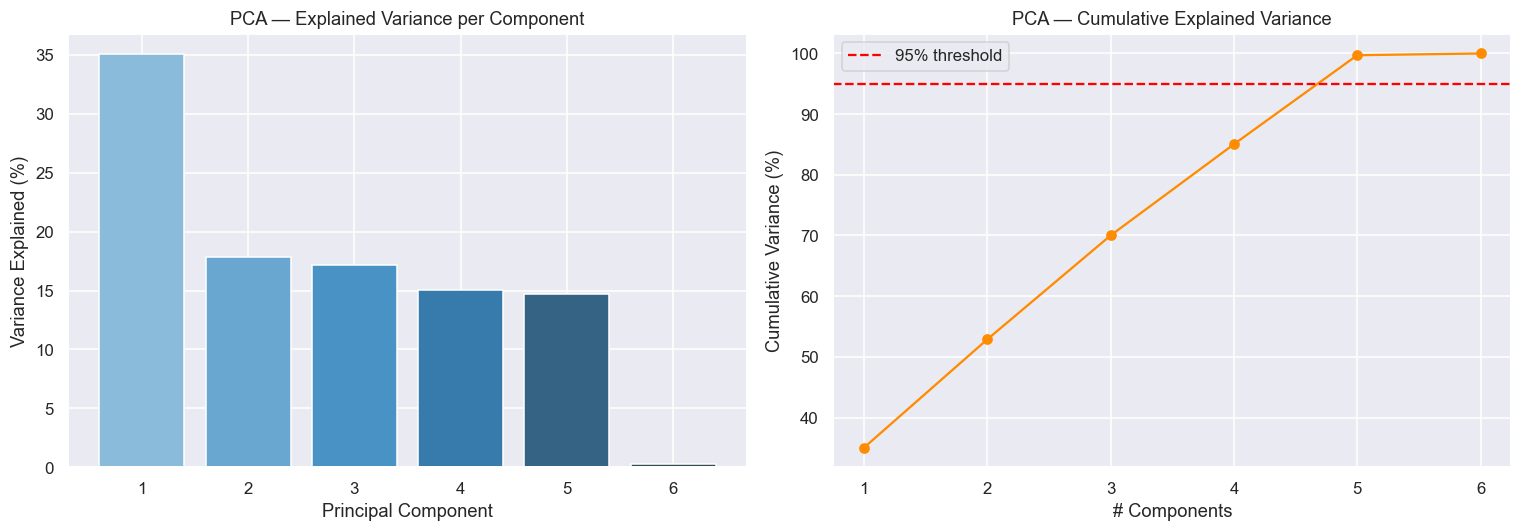


Components to explain 95% variance: 5


In [ ]:
# 3.5  Dimensionality Reduction using PCA 
print("PCA ...")
pca_features = POLLUTANTS
X_pca = main_df[pca_features].values
X_norm = MinMaxScaler().fit_transform(X_pca)

pca = PCA(n_components=len(pca_features))
pca.fit(X_norm)
exp_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(range(1, len(exp_var)+1), exp_var*100, color=sns.color_palette("Blues_d", len(exp_var)))
ax[0].set_xlabel("Principal Component"); ax[0].set_ylabel("Variance Explained (%)")
ax[0].set_title("PCA — Explained Variance per Component")

ax[1].plot(range(1,len(exp_var)+1), np.cumsum(exp_var)*100, "o-", color="darkorange")
ax[1].axhline(95, ls="--", color="red", label="95% threshold")
ax[1].set_xlabel("# Components"); ax[1].set_ylabel("Cumulative Variance (%)")
ax[1].set_title("PCA — Cumulative Explained Variance")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"\nComponents to explain 95% variance: {np.argmax(np.cumsum(exp_var) >= 0.95) + 1}")


##  Module 3: Exploratory Data Analysis (EDA) & Visualization


In [ ]:
# 4.1  Summary Statistics 
print("Summary Statistics ...")
summary = main_df[POLLUTANTS + ["aqi"]].describe().round(2)
print(summary.to_string())


── 4.1 Summary Statistics ──
         pm2_5     pm10      no2      so2       co       o3      aqi
count  2931.00  2931.00  2931.00  2931.00  2931.00  2931.00  2931.00
mean     94.97   146.91    54.65    18.42     1.25    30.59    99.57
std      56.72    89.07    24.96    10.42     0.71    14.26    55.78
min       0.02     0.03     0.13     0.01     0.00     0.04     0.00
25%      49.67    75.89    37.02    10.44     0.70    20.17    55.17
50%      91.21   140.13    53.99    17.95     1.21    30.41    95.53
75%     135.53   207.52    72.26    25.60     1.74    40.49   138.38
max     263.89   405.28   125.61    48.36     3.30    70.93   258.02


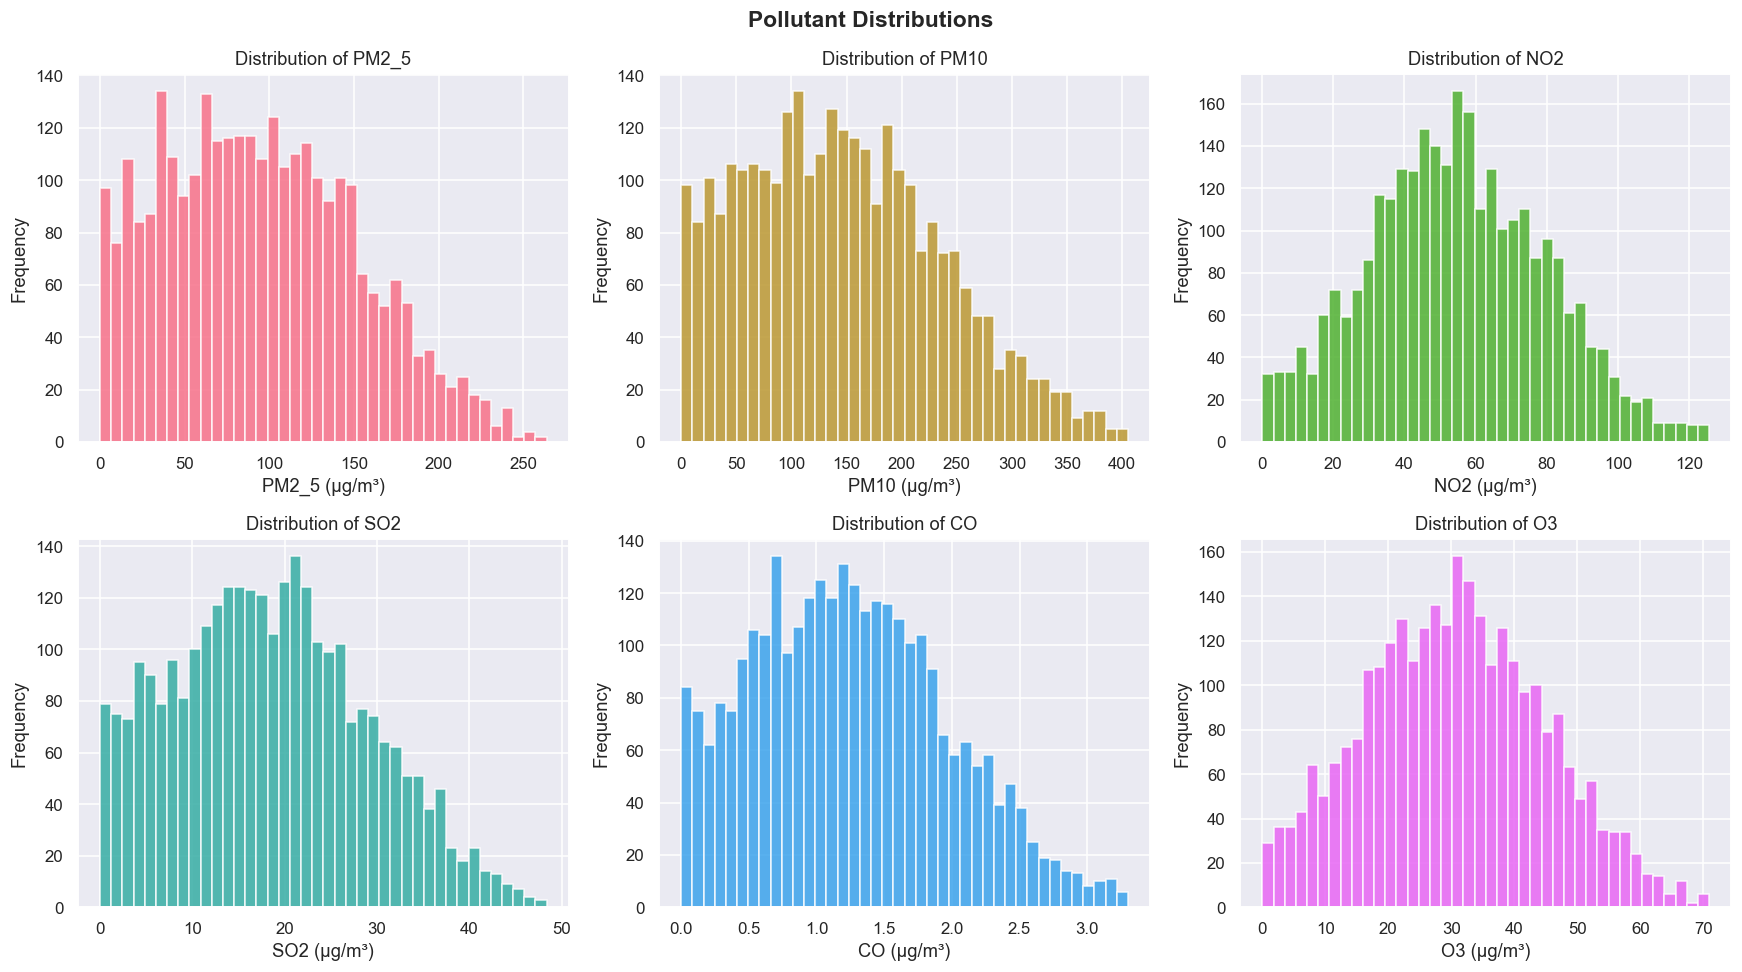

In [ ]:
# 4.2  Histograms 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = sns.color_palette("husl", 6)
for i, col in enumerate(POLLUTANTS):
    axes[i].hist(main_df[col].dropna(), bins=40, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Distribution of {col.upper()}")
    axes[i].set_xlabel(f"{col.upper()} (µg/m³)")
    axes[i].set_ylabel("Frequency")
plt.suptitle("Pollutant Distributions", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


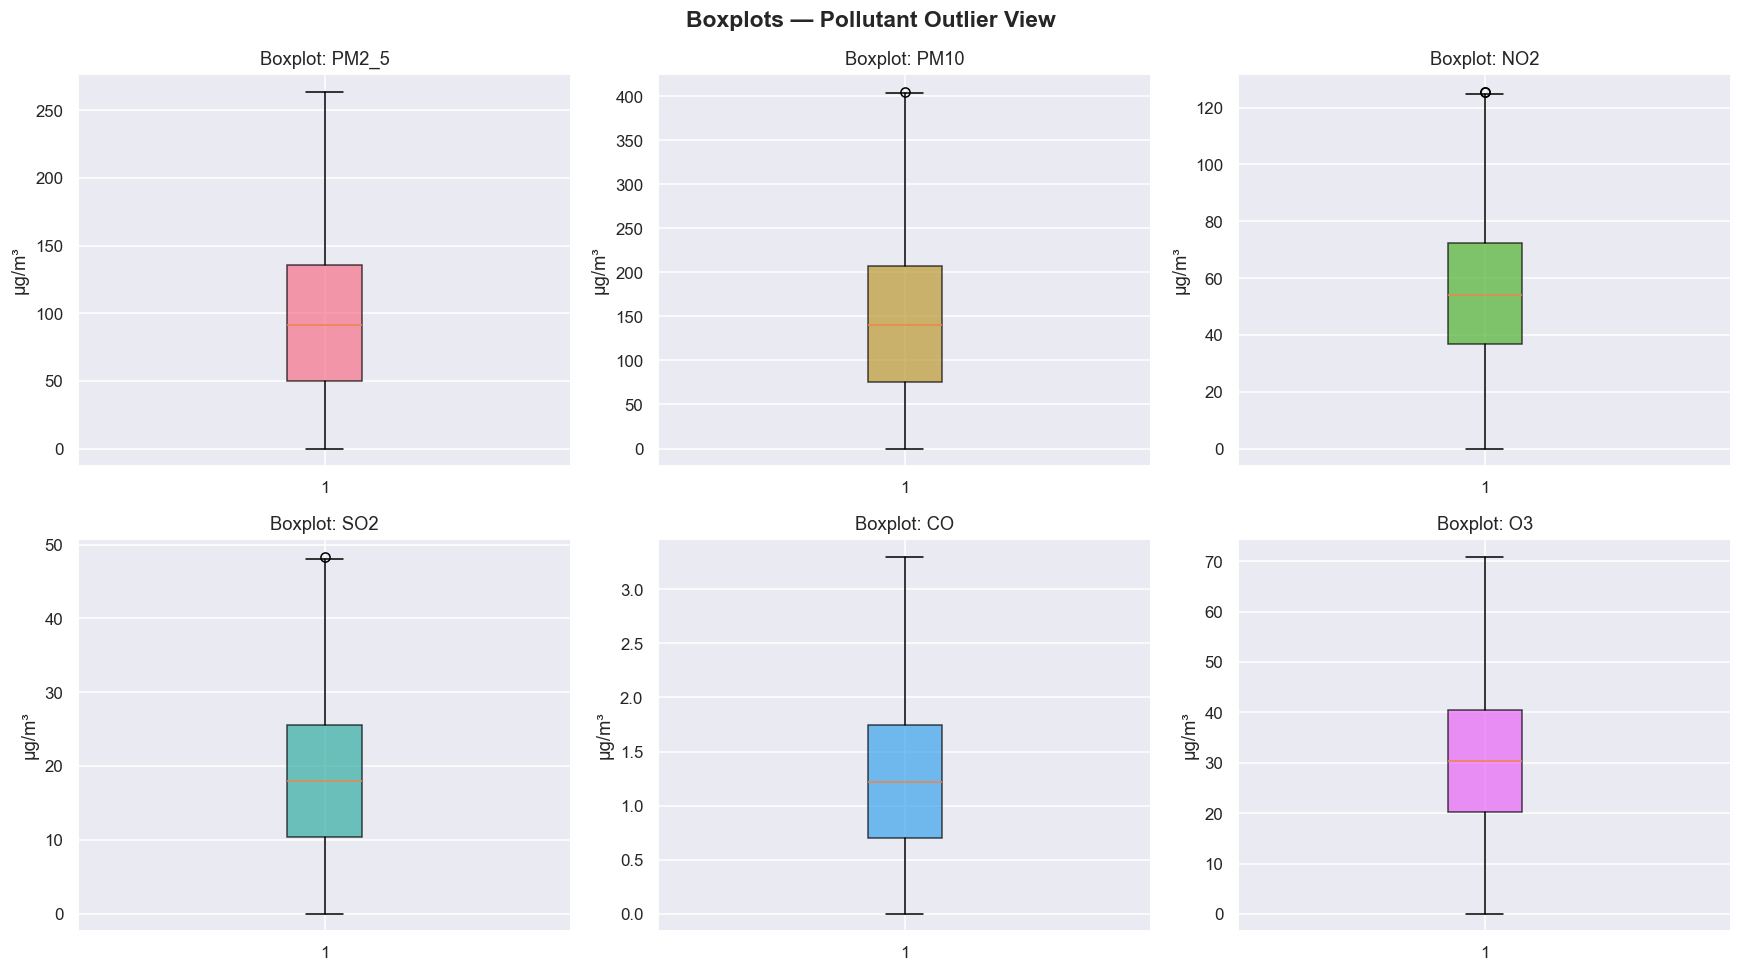

In [ ]:
# 4.3  Boxplots 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(POLLUTANTS):
    axes[i].boxplot(main_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7))
    axes[i].set_title(f"Boxplot: {col.upper()}")
    axes[i].set_ylabel("µg/m³")
plt.suptitle("Boxplots — Pollutant Outlier View", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()


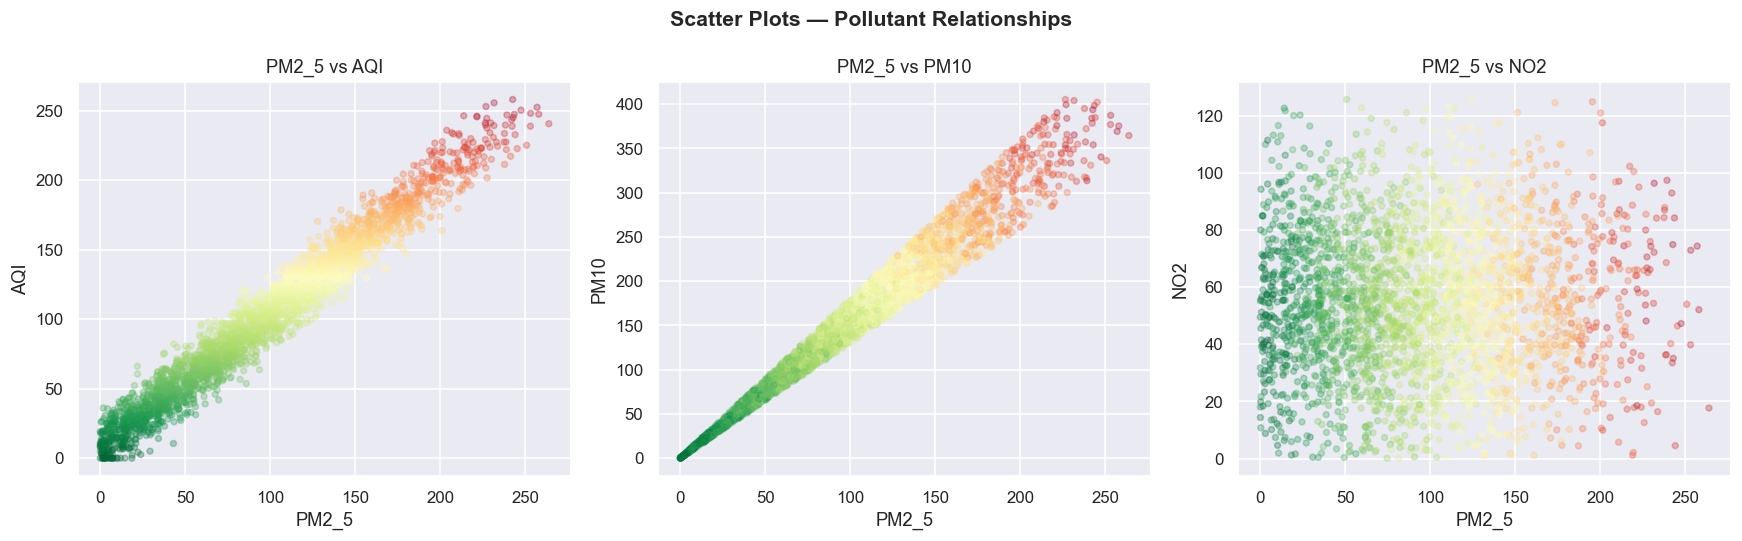

In [ ]:
# 4.4  Scatter Plots (PM2.5 vs other pollutants) 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [("pm2_5","aqi"), ("pm2_5","pm10"), ("pm2_5","no2")]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(main_df[x], main_df[y], alpha=0.3, s=15, 
               c=main_df["aqi"], cmap="RdYlGn_r")
    ax.set_xlabel(x.upper()); ax.set_ylabel(y.upper())
    ax.set_title(f"{x.upper()} vs {y.upper()}")
plt.suptitle("Scatter Plots — Pollutant Relationships", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


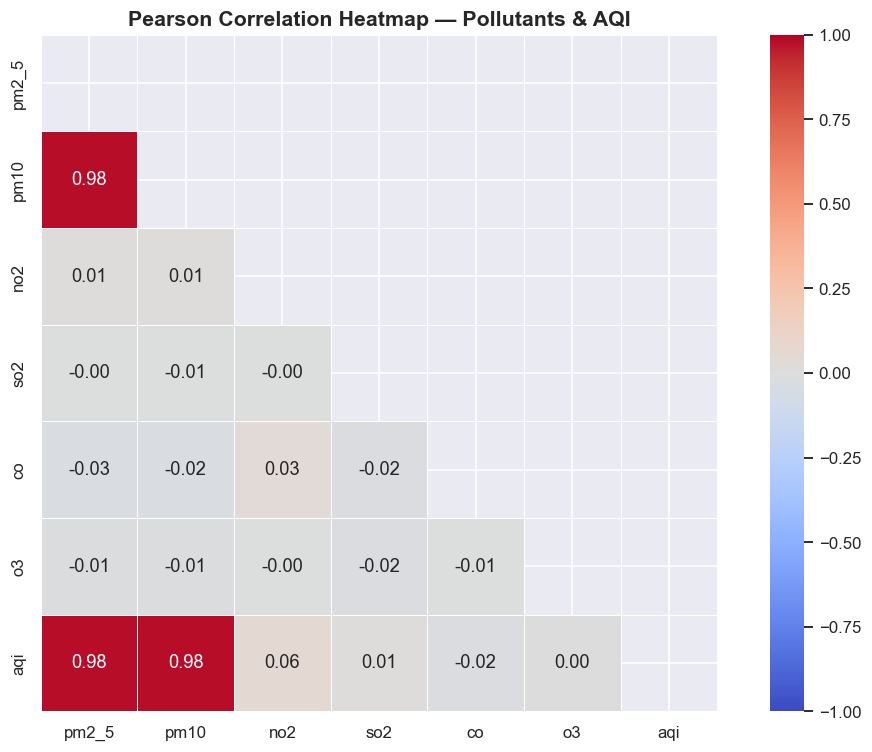

In [ ]:
# 4.5  Correlation Heatmap 
fig, ax = plt.subplots(figsize=(10, 7))
corr = main_df[POLLUTANTS + ["aqi"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True)
ax.set_title("Pearson Correlation Heatmap — Pollutants & AQI", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


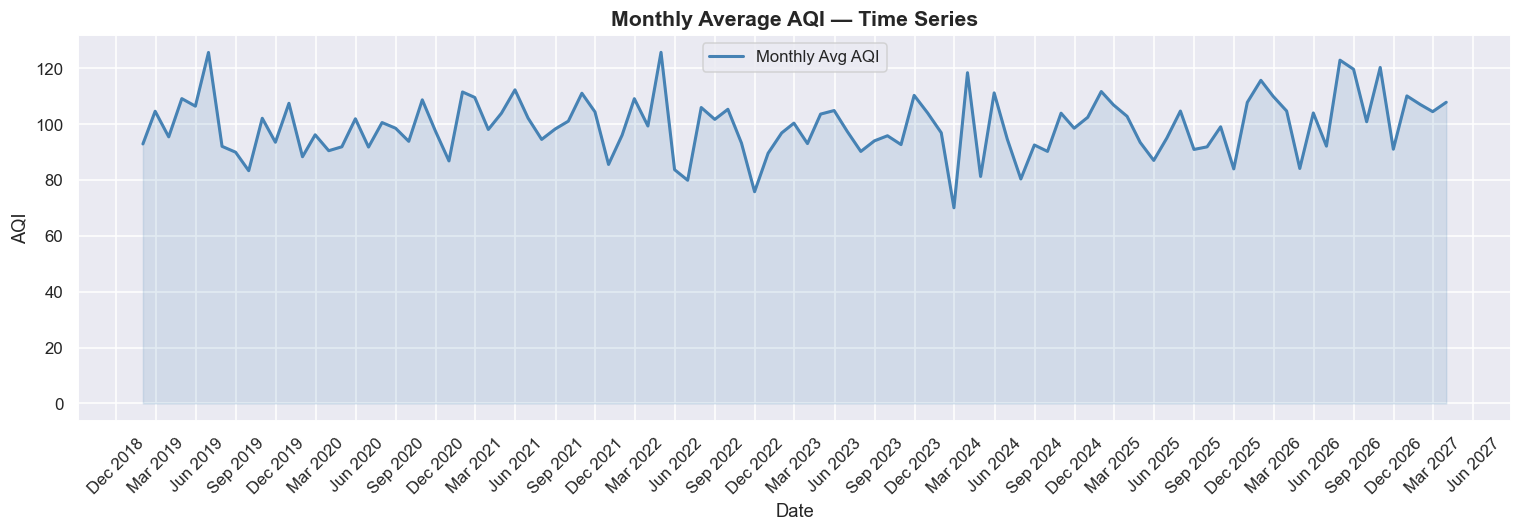

In [ ]:
# 4.6  Time-Series AQI Trend 
ts = main_df.set_index("datetime")["aqi"].resample("M").mean().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color="steelblue", linewidth=2, label="Monthly Avg AQI")
ax.fill_between(ts.index, ts.values, alpha=0.15, color="steelblue")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title("Monthly Average AQI — Time Series", fontsize=14, fontweight="bold")
ax.set_ylabel("AQI"); ax.set_xlabel("Date"); ax.legend()
plt.tight_layout(); plt.show()


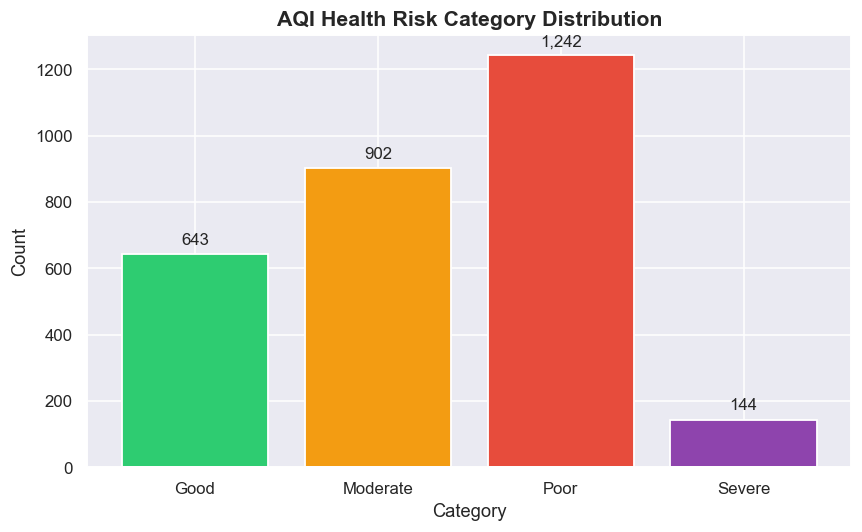

health_risk
Good         643
Moderate     902
Poor        1242
Severe       144


In [ ]:
# 4.7  AQI Category Distribution Bar Chart 
def aqi_category(v):
    if v <= 50:   return "Good"
    elif v <= 100: return "Moderate"
    elif v <= 200: return "Poor"
    else:          return "Severe"

main_df["health_risk"] = main_df["aqi"].apply(aqi_category)
cat_counts = main_df["health_risk"].value_counts()[["Good","Moderate","Poor","Severe"]]

fig, ax = plt.subplots(figsize=(8,5))
bar_colors = ["#2ecc71","#f39c12","#e74c3c","#8e44ad"]
bars = ax.bar(cat_counts.index, cat_counts.values, color=bar_colors, edgecolor="white", linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20,
            f"{b.get_height():,}", ha="center", va="bottom", fontsize=11)
ax.set_title("AQI Health Risk Category Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Category"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()
print(cat_counts.to_string())


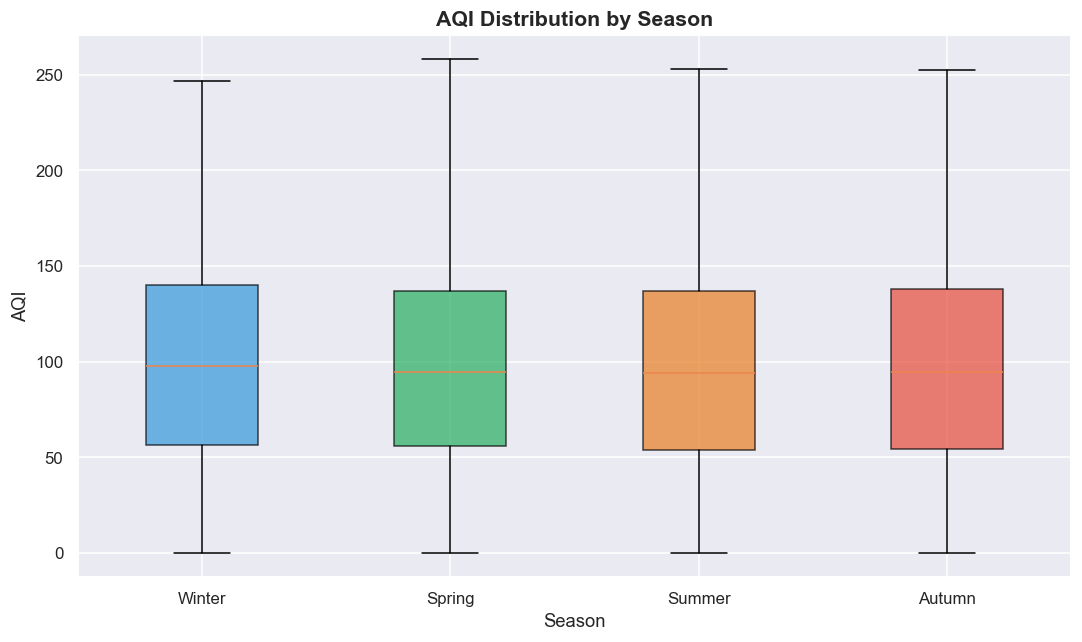

In [ ]:
# 4.8  Seasonal Box Plots 
fig, ax = plt.subplots(figsize=(10, 6))
season_data = [main_df[main_df["season"]==s]["aqi"].dropna() 
               for s in ["Winter","Spring","Summer","Autumn"]]
bp = ax.boxplot(season_data, labels=["Winter","Spring","Summer","Autumn"],
                patch_artist=True)
palette = ["#3498db","#27ae60","#e67e22","#e74c3c"]
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("AQI Distribution by Season", fontsize=14, fontweight="bold")
ax.set_ylabel("AQI"); ax.set_xlabel("Season")
plt.tight_layout(); plt.show()


##  Module 5: Statistical Foundations


In [ ]:
# 5.1  Descriptive Statistics 
print("Descriptive Statistics \n...")
for col in POLLUTANTS + ["aqi"]:
    arr = main_df[col].dropna()
  print(f"{col.upper():8s} | Mean={arr.mean():.2f} | Var={arr.var():.2f} | Std={arr.std():.2f} | "
          f"Median={arr.median():.2f} | Skew={arr.skew():.2f}")


── 5.1 Descriptive Statistics ──

PM2_5    | Mean=94.97 | Var=3216.63 | Std=56.72 | Median=91.21 | Skew=0.35
PM10     | Mean=146.91 | Var=7933.28 | Std=89.07 | Median=140.13 | Skew=0.41
NO2      | Mean=54.65 | Var=622.95 | Std=24.96 | Median=53.99 | Skew=0.15
SO2      | Mean=18.42 | Var=108.51 | Std=10.42 | Median=17.95 | Skew=0.28
CO       | Mean=1.25 | Var=0.51 | Std=0.71 | Median=1.21 | Skew=0.34
O3       | Mean=30.59 | Var=203.29 | Std=14.26 | Median=30.41 | Skew=0.13
AQI      | Mean=99.57 | Var=3111.17 | Std=55.78 | Median=95.53 | Skew=0.35


In [ ]:
# 5.2  Independent t-Test: Compare AQI between 2 cities 
print("Independent t-Test ...")
cities_list = main_df["city"].unique()
if len(cities_list) >= 2:
    c1, c2 = cities_list[0], cities_list[1]
    g1 = main_df[main_df["city"]==c1]["aqi"].dropna()
    g2 = main_df[main_df["city"]==c2]["aqi"].dropna()
    t_stat, p_val = ttest_ind(g1, g2, equal_var=False)
  print(f" Comparing AQI: {c1} (n={len(g1)}) vs {c2} (n={len(g2)})")
  print(f" t-statistic = {t_stat:.4f} | p-value = {p_val:.6f}")
    if p_val < 0.05:
    print("  SIGNIFICANT: AQI distributions differ significantly (p < 0.05)")
    else:
    print(" ❌ NOT significant at 0.05 level")


── 5.2 Independent t-Test ──
  Comparing AQI: Bangalore (n=463) vs Kolkata (n=522)
  t-statistic = -1.7644 | p-value = 0.077975
  ❌ NOT significant at 0.05 level


In [ ]:
# 5.3  Chi-Square Test: AQI Category vs Season 
print("Chi-Square Test ...")
contingency = pd.crosstab(main_df["season"], main_df["health_risk"])
print("Contingency Table:")
print(contingency.to_string())
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\n χ² = {chi2:.4f} | p = {p:.6f} | df = {dof}")
if p < 0.05:
  print("  SIGNIFICANT: AQI category depends on season (p < 0.05)")
else:
  print(" ❌ NOT significant")


── 5.3 Chi-Square Test ──
Contingency Table:
health_risk  Good  Moderate  Poor  Severe
season                                   
Winter        171       247   360      39
Spring        155       210   283      45
Summer        166       222   301      30
Autumn        151       223   298      30

  χ² = 7.2076 | p = 0.615514 | df = 9
  ❌ NOT significant


In [ ]:
# 5.4  One-Way ANOVA: AQI across cities 
print("ANOVA Test ...")
groups = [main_df[main_df["city"]==c]["aqi"].dropna() for c in main_df["city"].unique()]
f_stat, p_val = f_oneway(*groups)
print(f" F-statistic = {f_stat:.4f} | p-value = {p_val:.6f}")
if p_val < 0.05:
  print("  SIGNIFICANT: AQI varies significantly across cities")
else:
  print(" ❌ NOT significant")


── 5.4 ANOVA Test ──
  F-statistic = 1.2462 | p-value = 0.284720
  ❌ NOT significant


In [ ]:
# 5.5  Pearson & Spearman Correlations (PM2.5 vs AQI) 
print("Correlation Analysis ...")
x = main_df["pm2_5"].dropna()
y = main_df["aqi"].loc[x.index]

pearson_r,  pearson_p  = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print(f" Pearson r = {pearson_r:.4f} | p = {pearson_p:.2e}")
print(f" Spearman r = {spearman_r:.4f} | p = {spearman_p:.2e}")
print(f" → PM2.5 {'strongly' if abs(pearson_r)>0.7 else 'moderately'} correlates with AQI")


── 5.5 Correlation Analysis ──
  Pearson  r = 0.9788  | p = 0.00e+00
  Spearman r = 0.9791  | p = 0.00e+00
  → PM2.5 strongly correlates with AQI


##  Module 4: Machine Learning Basics


In [ ]:
# 6.1  Feature Matrix 
ML_FEATURES = ["pm2_5","pm10","no2","so2","co","o3",
               "pm25_lag1","pm25_lag3","pm25_lag7",
               "pm25_roll3","pm25_roll7","pm25_rollstd7",
               "month","day_of_year","day_of_week","city_enc"]

df_ml = main_df[ML_FEATURES + ["aqi","health_risk"]].dropna().reset_index(drop=True)
le_risk = LabelEncoder()
df_ml["risk_enc"] = le_risk.fit_transform(df_ml["health_risk"])

X = df_ml[ML_FEATURES].values
y_reg = df_ml["aqi"].values
y_cls = df_ml["risk_enc"].values

# Chronological 80:20 split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]
y_cls_train, y_cls_test = y_cls[:split], y_cls[split:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 2344 | Test size: 587


── 6.2 AQI Regression ──
  MSE  = 112.65
  RMSE = 10.61
  R²   = 0.9659


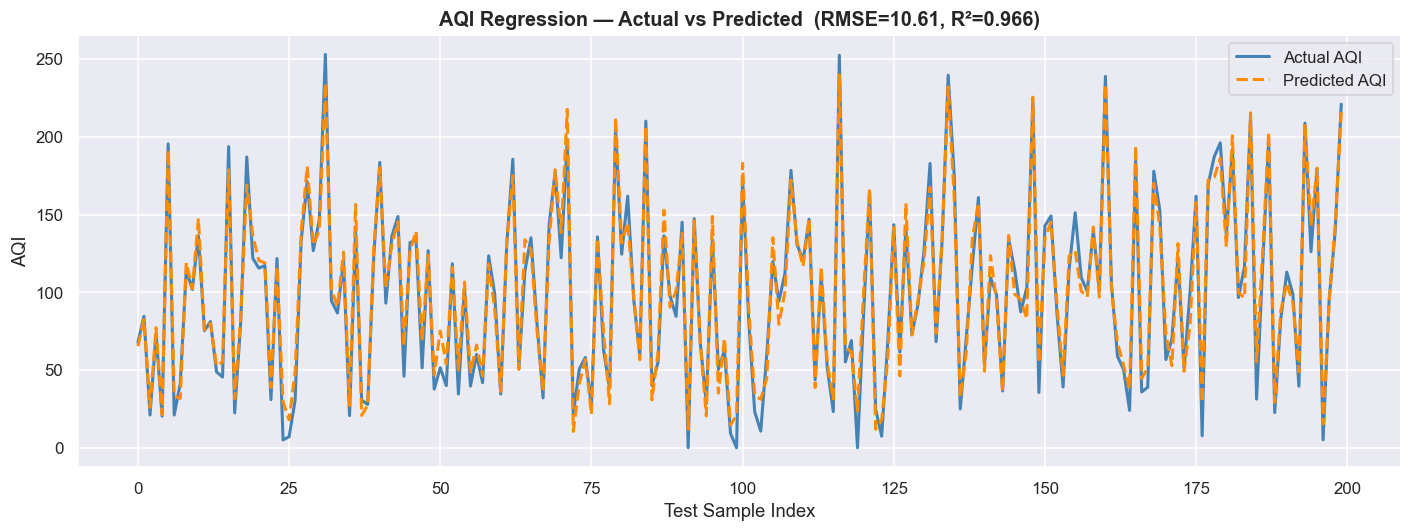

In [ ]:
# 6.2  Supervised: AQI Regression (Random Forest) 
print("AQI Regression ...")
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
y_pred_reg = rf_reg.predict(X_test)

mse  = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_reg_test, y_pred_reg)

print(f" MSE = {mse:.2f}")
print(f" RMSE = {rmse:.2f}")
print(f" R²  = {r2:.4f}")

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(y_reg_test[:200], label="Actual AQI", lw=2, color="steelblue")
ax.plot(y_pred_reg[:200], label="Predicted AQI", lw=2, color="darkorange", ls="--")
ax.set_title(f"AQI Regression — Actual vs Predicted  (RMSE={rmse:.2f}, R²={r2:.3f})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Test Sample Index"); ax.set_ylabel("AQI")
ax.legend(); plt.tight_layout(); plt.show()


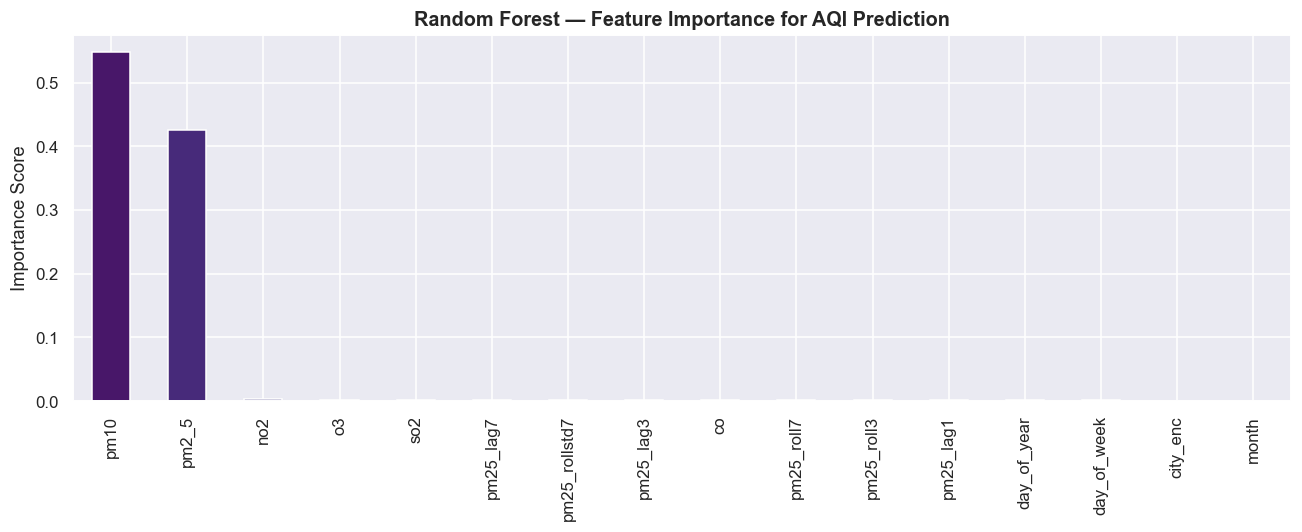

In [ ]:
# 6.3  Feature Importance 
importances = pd.Series(rf_reg.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12,5))
importances.plot(kind="bar", ax=ax, color=sns.color_palette("viridis", len(importances)))
ax.set_title("Random Forest — Feature Importance for AQI Prediction",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Importance Score")
plt.tight_layout(); plt.show()


In [ ]:
# 6.4  Supervised: Health Risk Classification 
print("Health Risk Classification ...")
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=12,
                                  random_state=42, n_jobs=-1)
rf_cls.fit(X_train, y_cls_train)
y_pred_cls = rf_cls.predict(X_test)

acc = accuracy_score(y_cls_test, y_pred_cls)
print(f" Accuracy = {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_cls_test, y_pred_cls,
      target_names=le_risk.classes_))


── 6.4 Health Risk Classification ──
  Accuracy = 89.10%

Classification Report:
              precision    recall  f1-score   support

        Good       0.92      0.85      0.89       124
    Moderate       0.81      0.86      0.83       169
        Poor       0.93      0.93      0.93       257
      Severe       0.94      0.92      0.93        37

    accuracy                           0.89       587
   macro avg       0.90      0.89      0.89       587
weighted avg       0.89      0.89      0.89       587



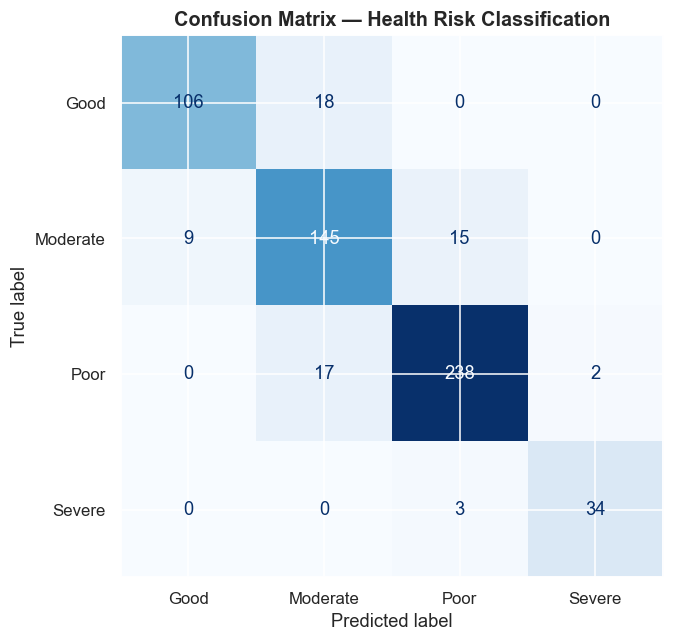

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_cls_test, y_pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=le_risk.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Health Risk Classification",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


── 6.5 K-Means Clustering ──


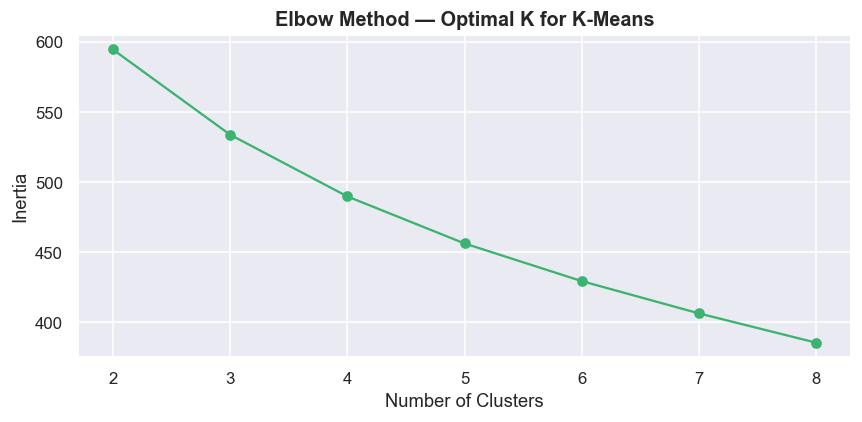

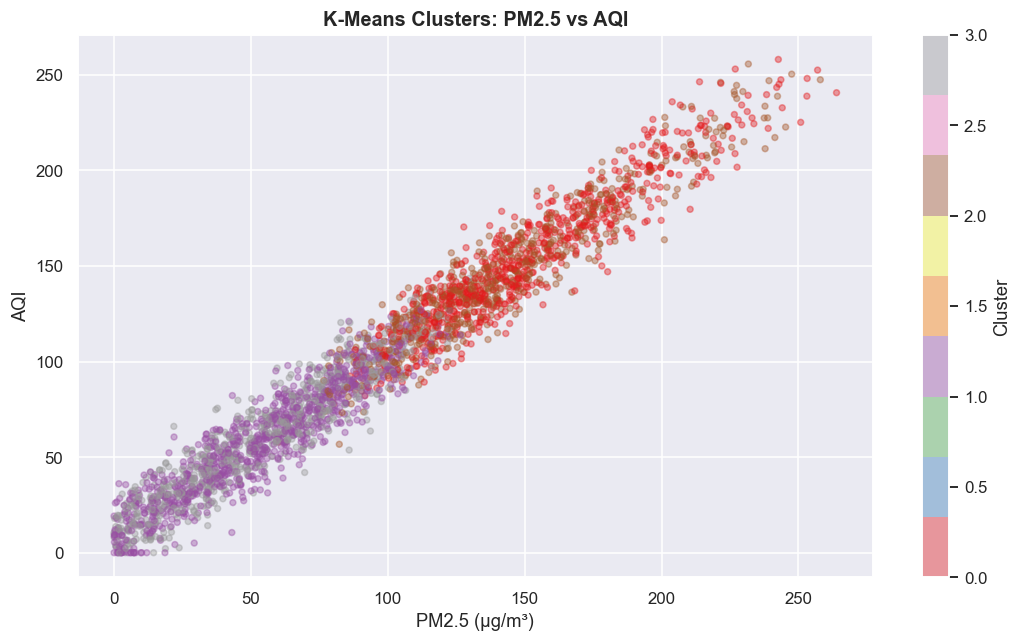

In [ ]:
# 6.5  Unsupervised: K-Means Clustering of Pollution Patterns 
print("K-Means Clustering ...")
X_cluster = MinMaxScaler().fit_transform(main_df[POLLUTANTS].dropna())

inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(K_range, inertia, "o-", color="mediumseagreen")
ax.set_title("Elbow Method — Optimal K for K-Means", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Clusters"); ax.set_ylabel("Inertia")
plt.tight_layout(); plt.show()

# Fit optimal
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
main_df["cluster"] = np.nan
valid_idx = main_df[POLLUTANTS].dropna().index
main_df.loc[valid_idx, "cluster"] = km_final.fit_predict(X_cluster)

fig, ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(main_df["pm2_5"], main_df["aqi"],
                     c=main_df["cluster"], cmap="Set1", alpha=0.4, s=15)
ax.set_title("K-Means Clusters: PM2.5 vs AQI", fontsize=13, fontweight="bold")
ax.set_xlabel("PM2.5 (µg/m³)"); ax.set_ylabel("AQI")
plt.colorbar(scatter, ax=ax, label="Cluster"); plt.tight_layout(); plt.show()


##  Health Risk Reporting & Advisories


*Data Source Note: The AQI predictions and advisories below are derived from our models trained on the OpenAQ API and CPCB (data.gov.in) datasets fetched earlier.*

In [ ]:
# 7.1  Predict Next-Day AQI (using last row of data) 
print("AQI Forecast & Health Advisory \n...")

last_row = df_ml[ML_FEATURES].iloc[-1].values.reshape(1, -1)
pred_aqi  = rf_reg.predict(last_row)[0]
pred_risk = le_risk.inverse_transform(rf_cls.predict(last_row))[0]

advisories = {
    "Good":     "✅ Air quality is satisfactory. Enjoy outdoor activities!",
    "Moderate": "⚠️  Sensitive individuals (asthma, heart disease) should limit prolonged outdoor exertion.",
    "Poor":     "🟠 Everyone may experience health effects. Reduce outdoor activities. Wear a mask.",
    "Severe":   "🔴 Health alert! Everyone should avoid outdoor activities. Stay indoors. Use air purifiers.",
}

print(f" 📍 Location  : {main_df['city'].iloc[-1]}")
print(f" 📅 Based on  : {main_df['datetime'].iloc[-1].date()}")
print(f" 🔮 Predicted AQI  : {pred_aqi:.1f}")
print(f" 🏥 Health Risk   : {pred_risk}")
print(f" 💬 Advisory    : {advisories.get(pred_risk, 'Monitor conditions closely.')}")


AQI Forecast & Health Advisory 
...
 📍 Location  : Kolkata
 📅 Based on  : 2027-03-17
 🔮 Predicted AQI  : 99.5
 🏥 Health Risk   : Poor
 💬 Advisory    : 🟠 Everyone may experience health effects. Reduce outdoor activities. Wear a mask.


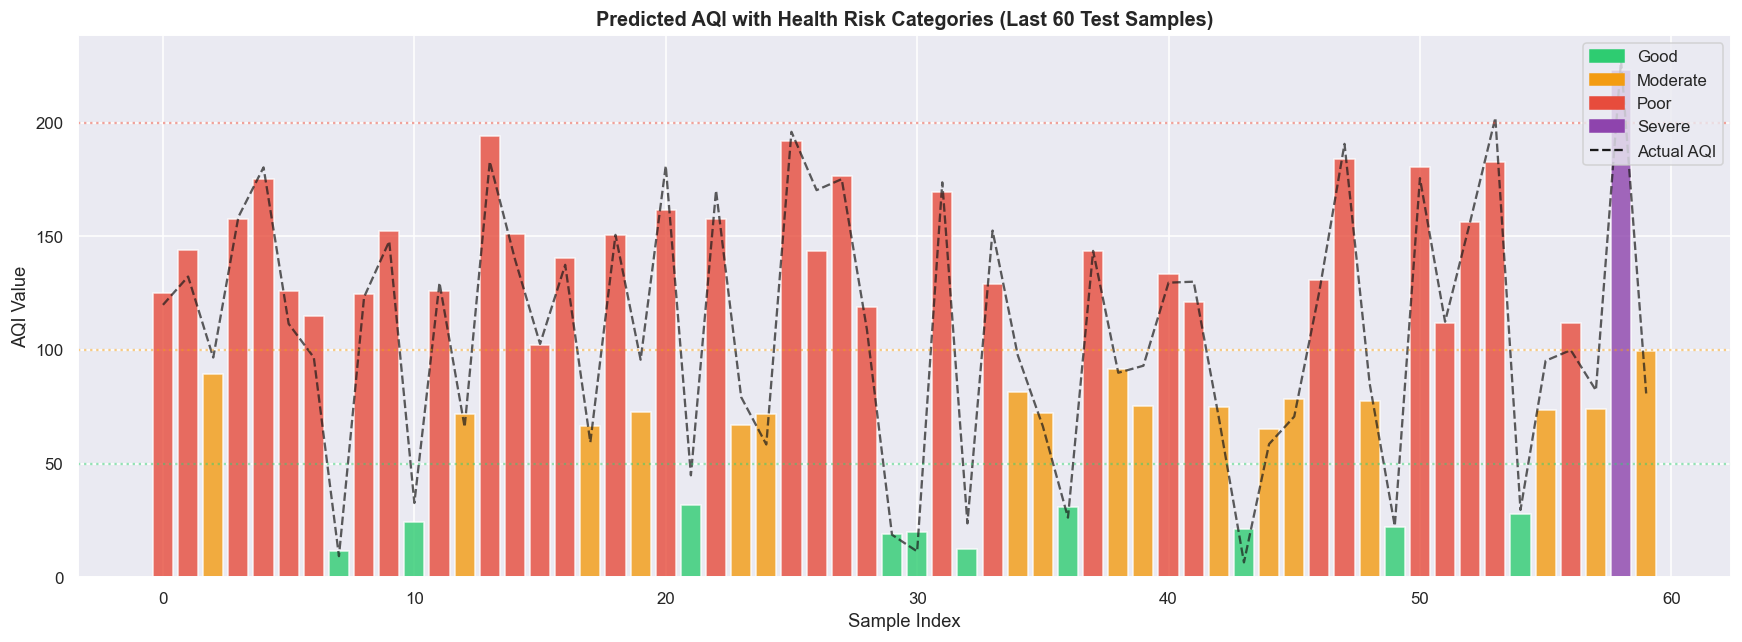

In [ ]:
# 7.2  Batch Forecast Visualization 
# Predict on last 60 test samples and show health categories
sample_preds = y_pred_reg[-60:]
sample_true  = y_reg_test[-60:]
sample_risk  = [aqi_category(v) for v in sample_preds]

risk_colors_map = {"Good":"#2ecc71","Moderate":"#f39c12","Poor":"#e74c3c","Severe":"#8e44ad"}
bar_cols = [risk_colors_map[r] for r in sample_risk]

fig, ax = plt.subplots(figsize=(16,6))
x_idx = range(len(sample_preds))
ax.bar(x_idx, sample_preds, color=bar_cols, alpha=0.8, label="Predicted AQI")
ax.plot(x_idx, sample_true, "k--", lw=1.5, alpha=0.7, label="Actual AQI")

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l,c in risk_colors_map.items()]
legend_handles.append(plt.Line2D([0],[0], color="k", ls="--", label="Actual AQI"))
ax.legend(handles=legend_handles, loc="upper right")

ax.axhline(50,  color="#2ecc71", ls=":",  alpha=0.5)
ax.axhline(100, color="#f39c12", ls=":",  alpha=0.5)
ax.axhline(200, color="#e74c3c", ls=":",  alpha=0.5)
ax.set_title("Predicted AQI with Health Risk Categories (Last 60 Test Samples)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Sample Index"); ax.set_ylabel("AQI Value")
plt.tight_layout(); plt.show()


In [ ]:
# 7.3  Final Summary 
print("=" * 60)
print(" PROJECT SUMMARY — AQI PREDICTION & HEALTH RISK SYSTEM")
print("=" * 60)
print(f" Dataset size     : {len(main_df):,} rows")
print(f" Features used    : {len(ML_FEATURES)}")
print(f" Regression RMSE   : {rmse:.2f}")
print(f" Regression R²    : {r2:.4f}")
print(f" Classification Acc. : {acc*100:.2f}%")
print(f" Pearson r (PM2.5~AQI): {pearson_r:.4f}")
print()
print(" Modules Demonstrated:")
print(" [M1] Python, NumPy, Pandas")
print(" [M2] Data Wrangling, PCA, Encoding, Lag Features")
print(" [M3] EDA, Histograms, Boxplots, Heatmap, Time-Series")
print(" [M4] Random Forest (Regressor + Classifier), K-Means")
print(" [M5] t-test, Chi-Square, ANOVA, Pearson, Spearman")
print("=" * 60)


  PROJECT SUMMARY — AQI PREDICTION & HEALTH RISK SYSTEM
  Dataset size         : 2,931 rows
  Features used        : 16
  Regression RMSE      : 10.61
  Regression R²        : 0.9659
  Classification Acc.  : 89.10%
  Pearson r (PM2.5~AQI): 0.9788

  Modules Demonstrated:
  [M1] Python, NumPy, Pandas
  [M2] Data Wrangling, PCA, Encoding, Lag Features
  [M3] EDA, Histograms, Boxplots, Heatmap, Time-Series
  [M4] Random Forest (Regressor + Classifier), K-Means
  [M5] t-test, Chi-Square, ANOVA, Pearson, Spearman
